In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using {device} device')

Using cuda device


In [4]:
# 데이터 로딩
path = 'https://bit.ly/ds_boston_csv'
data = pd.read_csv(path)


# x, y 분할
target = 'medv'
features = ['lstat', 'ptratio', 'crim']
x = data.loc[:, features]
y = data.loc[:, target]


# train, val 분할
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=.2, random_state = 20)


# 스케일러 선언
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)


In [5]:
# 데이터 로더 함수
def make_DataSet(x_train, x_val, y_train, y_val, batch_size = 32) :
    # 데이터 텐서로 변환
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)


    # TensorDataset 생성: 텐서 데이터 세트로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)


    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle = True)


    return train_loader, x_val_tensor, y_val_tensor


In [6]:
# 데이터프레임을 넘파이 배열로 변환
print(type(y_train), type(y_val))
y_train = y_train.values
y_val = y_val.values
print(type(y_train), type(y_val))


<class 'pandas.Series'> <class 'pandas.Series'>
<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [7]:
# make_DataSet 함수로 데이터 로더를 구성
train_loader, x_val_ts, y_val_ts = make_DataSet(x_train, x_val, y_train, y_val, 32)


# 첫 번째 배치만 로딩해서 살펴보기
for x, y in train_loader:
    print(f'Shape of x [rows, columns]: {x.shape}')
    print(f'Shape of y: {y.shape} {y.dtype}')
    break


Shape of x [rows, columns]: torch.Size([32, 3])
Shape of y: torch.Size([32, 1]) torch.float32


In [8]:
n_feature = x.shape[1]
model1 = nn.Sequential(nn.Linear(n_feature, 1)).to(device)


loss_fn = nn.MSELoss()
optimizer = Adam(model1.parameters(), lr=0.01)
print(model1)


Sequential(
  (0): Linear(in_features=3, out_features=1, bias=True)
)


In [9]:
def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    tr_loss = 0
    model.train()
    for x, y in dataloader:
        x, y = x.to(device), y.to(device)
        pred = model(x)
        loss = loss_fn(pred, y)
        tr_loss += loss
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    tr_loss /= num_batches
    return tr_loss.item()


In [ ]:
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval()
    with torch.no_grad():   # 평가할 거라 미분 안 함. 미분 자체가 학습.
        x, y = x_val_tensor.to(device), y_val_tensor.to(device)
        pred = model(x)
        val_loss = loss_fn(pred, y).item()
    return val_loss, pred


In [12]:
epochs = 1000
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model1, loss_fn, optimizer, device)
    val_loss, _ = evaluate(x_val_ts, y_val_ts, model1, loss_fn, device)
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    print(f'Epoch {t+1}, train loss: {tr_loss:4f}, val loss: {val_loss:4f}')


Epoch 1, train loss: 112.174713, val loss: 79.965050
Epoch 2, train loss: 113.916328, val loss: 79.721848
Epoch 3, train loss: 110.524467, val loss: 79.477936
Epoch 4, train loss: 110.515007, val loss: 79.233528
Epoch 5, train loss: 110.860992, val loss: 78.980911
Epoch 6, train loss: 111.459511, val loss: 78.733963
Epoch 7, train loss: 110.450615, val loss: 78.490295
Epoch 8, train loss: 109.776909, val loss: 78.244270
Epoch 9, train loss: 110.851448, val loss: 78.008202
Epoch 10, train loss: 112.151825, val loss: 77.778282
Epoch 11, train loss: 108.372444, val loss: 77.540596
Epoch 12, train loss: 108.539436, val loss: 77.290863
Epoch 13, train loss: 107.072708, val loss: 77.061768
Epoch 14, train loss: 107.565826, val loss: 76.821945
Epoch 15, train loss: 107.643219, val loss: 76.583153
Epoch 16, train loss: 106.535896, val loss: 76.369881
Epoch 17, train loss: 106.142487, val loss: 76.133148
Epoch 18, train loss: 106.982353, val loss: 75.895615
Epoch 19, train loss: 106.100067, val

In [13]:
# 학습곡선 함수
def dl_learning_curve(tr_loss_list, val_loss_list):
    epochs = list(range(1, len(tr_loss_list)+1))
    plt.plot(epochs, tr_loss_list, label='train_err', marker = '.')
    plt.plot(epochs, val_loss_list, label='val_err', marker = '.')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()


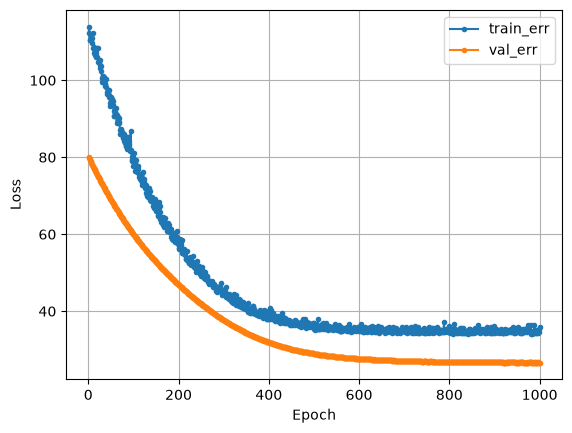

In [ ]:
# 학습 곡선
dl_learning_curve(tr_loss_list, val_loss_list)

In [15]:
_, pred = evaluate(x_val_ts, y_val_ts, model1, loss_fn, device)
mae = mean_absolute_error(y_val_ts.cpu().numpy(), pred.cpu().numpy())
mape = mean_absolute_percentage_error(y_val_ts.cpu().numpy(), pred.cpu().numpy())
print(f'MAE : {mae}')
print(f'MAPE : {mape}')

MAE : 3.793022632598877
MAPE : 0.17530183494091034
